In [1]:
import torch
import torchvision.transforms as transforms

In [29]:
import torch
import torch.nn as nn

class MyModule(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(in_features, out_features, bias=False),
            nn.Sequential(
                nn.Conv1d(in_channels=out_features, out_channels=out_features,
                          kernel_size=3),
                nn.BatchNorm1d(out_features)
            )
        )
        # print('a initial:\n', self.a.weight)
        # Register a hook on self.a
        # self.a.weight.register_hook(self.update_a)

    def forward(self, x):
        # print('FORWARD self.a:\n', self.a.weight)
        return self.a(x)

    def update_a(self, grad):
        # Define the update logic for self.a
        # You can modify self.a based on the gradients or any other logic
        # self.a = self.a + 0.1 * grad  # Example update logic
        print('\nHOOK A')
        # print('self.a:\n', self.a.weight)
        # with torch.no_grad():
        #     self.a.weight.add_(0.01)
        # print('self.a:\n', self.a.weight)
        

# Example usage
model = MyModule(2, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


def loop_over_sequence(seq):
    print('\nLOOP OVER SEQUENCE')
    for elem in seq:
        print(type(elem))
        if type(elem) == nn.Sequential:
            loop_over_sequence(elem)

loop_over_sequence(model.seq)


x = torch.randn(10, 2)
target = x * (2. + -3*x)
compute_loss = nn.MSELoss()
num_epochs = 3

if False:
    model.train()
    # Training loop
    for _ in range(num_epochs):
        optimizer.zero_grad()
        output = model(x)

        print('\nloss')
        loss = compute_loss(output, target)
        print('loss.backward')
        print(model.a.weight)
        loss.backward()
        print('optimizer.step')
        print(model.a.weight)
        optimizer.step()
        print('end of iter')
        print(model.a.weight)

        # The update_a function will be automatically called after optimizer.step()
        # You can access the updated value of self.a here
        # updated_a = model.a



LOOP OVER SEQUENCE
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.container.Sequential'>

LOOP OVER SEQUENCE
<class 'torch.nn.modules.conv.Conv1d'>
<class 'torch.nn.modules.batchnorm.BatchNorm1d'>


In [100]:
import torch
import numpy as np
t = torch.arange(48, dtype=float).reshape(2,2,3,4)
for i in range(4):
    a = np.arange( 12*(i), 12*(i+1))
    print(a.sum(), a.mean(), ((a-a.mean())**2).sum())
    

def center_tensor2d(t):
    t.add_(-t.mean((-1,-2)).reshape(t.shape[:-2] + (1,1)))


def normalize_centered_tensor(t):
    t.mul_((1./torch.sqrt((t*t).sum((-1, -2)))).reshape(t.shape[:-2]+(1, 1)))

print(t)
print(t.sum())
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)
center_tensor2d(t)
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)

print((t*t).sum((-1, -2)))
normalize_centered_tensor(t)
print((t*t).sum((-1, -2)))

66 5.5 143.0
210 17.5 143.0
354 29.5 143.0
498 41.5 143.0
tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]],

         [[12., 13., 14., 15.],
          [16., 17., 18., 19.],
          [20., 21., 22., 23.]]],


        [[[24., 25., 26., 27.],
          [28., 29., 30., 31.],
          [32., 33., 34., 35.]],

         [[36., 37., 38., 39.],
          [40., 41., 42., 43.],
          [44., 45., 46., 47.]]]], dtype=torch.float64)
tensor(1128., dtype=torch.float64)
tensor([[143., 143.],
        [143., 143.]], dtype=torch.float64)
tensor([[1., 1.],
        [1., 1.]], dtype=torch.float64)


tensor(-0.9997)
tensor(-0.0027)
tensor(-0.0027)


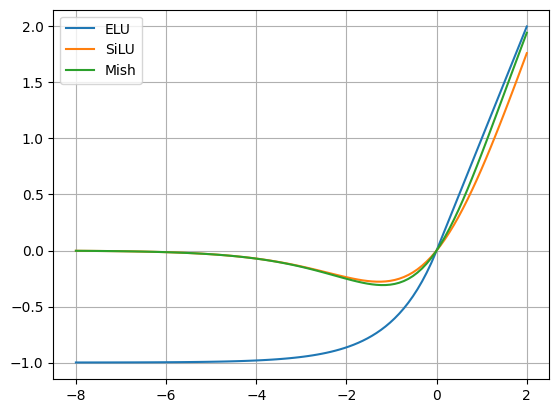

In [94]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

x = torch.linspace(-8, 2, 100)

fig, ax = plt.subplots()
for (func, label) in [(nn.ELU(), 'ELU'),
                      (nn.SiLU(), 'SiLU'),
                      (nn.Mish(), 'Mish'),
                      ]:
    y = func(x)
    ax.plot(x.numpy(), y.numpy(), label=label)
    print(y[0])
ax.grid(visible=True)
ax.legend()

In [107]:
import numpy as np

a = np.random.random(30)
seek = ( (a-a.mean())**2 ).sum()
print( seek )
print()
print( '1:', (a*a).sum() )
# print( a.mean()**2 )
print( '2:', a.sum()**2 / 30 )
print( '3:', (a*a).mean() )
val = (a*a).sum() - a.sum()**2 / a.size
print( val )
print()
print(val-seek)

2.5191687406383023

1: 7.2847973329341755
2: 4.765628592295873
3: 0.24282657776447253
2.5191687406383023

0.0


# ZNCC

In [3]:
import torch.nn as nn
seq = nn.Sequential(
    nn.Conv2d(3, 5, 3),
    nn.MaxPool2d(3)
)
print(seq)
for layer in seq:
    print(isinstance(layer, nn.Conv2d))

Sequential(
  (0): Conv2d(3, 5, kernel_size=(3, 3), stride=(1, 1))
  (1): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
)
True
False


In [9]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import pearsonr

import torch.nn.functional as F

def init_he(layer):
    with torch.no_grad():
        # He, recommanded with (leaky) relu only (pytorch)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in',
                                 nonlinearity='leaky_relu')
        if hasattr(layer, 'bias') and (layer.bias is not None):
            nn.init.constant_(layer.bias, 0.)

def center_tensor3d(t):
    t.add_(-t.mean((-1, -2, -3), keepdim=True))


def normalize_tensor3d(t):
    factors = 1. / torch.sqrt((t*t).sum((-1, -2, -3), keepdim=True))
    t.mul_(factors)


class ZNCC2d(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 kernel_size: int,
                 stride: int,
                 padding: int,
                 sublayers: int = 1,
                 bias: bool = True,
                 BatchNorm: bool = False,
                 activation: str = None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
        self.BatchNorm = BatchNorm
        self.activation = activation
        # self.pattern = nn.Conv2d(
        #     in_channels=in_channels,
        #     out_channels=out_channels,
        #     kernel_size=kernel_size,
        #     stride=stride,
        #     padding=padding,
        #     bias=False
        # )
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size,) * 2
        self.paddings_ = ((kernel_size[1]-1),)*2 + ((kernel_size[0]-1),)*2
        self.dirac = torch.zeros((in_channels, in_channels,
                                  2*kernel_size[0]-1,
                                  2*kernel_size[1]-1),
                                 dtype=torch.float)
        for i in range(self.in_channels):
                self.dirac[i, i, kernel_size[0]-1, kernel_size[1]-1] = 1.
        layer = [nn.Conv2d(
            in_channels=in_channels if i == 0 else out_channels,
            out_channels=out_channels,
            kernel_size=[k - 2*(sublayers-1) for k in kernel_size]
            if i == 0 else 3,
            stride=stride if i == sublayers-1 else 1,
            padding=padding if i == 0 else 0,
            groups=1 if i == 0 else out_channels,
            bias=False,
        ) for i in range(sublayers)]
        for cl in layer:
            init_he(cl)
        self.patterns = nn.Sequential(*layer)
        self.sum2d = nn.AvgPool2d(
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            divisor_override=1,
        )
        self.sum2d_ = nn.AvgPool2d(
            kernel_size=3,
            stride=1,
            padding=2,
            divisor_override=1,
        )
        self.size_ = kernel_size**2 if isinstance(kernel_size, int)\
            else kernel_size[0] * kernel_size[1]
        self.size_ *= in_channels
        self.reset_parameters()
        # self.center_norm_pattern()
        final = []
        if BatchNorm:
            final.append(nn.BatchNorm(out_channels))
        if activation is not None:
            final.append(activations[activation])
        if len(final) == 0:
            self.final = nn.Identity()
        else:
            self.final = nn.Sequential(*final)

    def reset_parameters(self):
        # nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        for layer in self.patterns:
            init_he(layer)
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1. / torch.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def get_patterns(self):
        with torch.no_grad():
            patterns = self.patterns(self.dirac)
        return patterns

    def center_norm_pattern(self):
        with torch.no_grad():
            for layer in self.patterns:
                # keep small weights
                normalize_tensor3d(layer.weight)

            # normalize each composed filter
            patterns = self.get_patterns()
            self.avg = patterns.mean((-1, -2, 0), keepdim=True)

            patterns.add_(-self.avg)
            factors = 1. / torch.sqrt((patterns*patterns).sum((-1, -2, 0),
                                                               keepdim=True))
            # print('factors:', factors.shape)
            # print('weight:', self.patterns[0].weight.shape)
            self.patterns[0].weight.data *= factors.reshape(-1, 1, 1, 1)
            # self.avg = self.get_patterns().mean((-1, -2, 0)).reshape(-1, 1, 1)
            self.avg *= factors.reshape(-1, 1, 1)


    def forward(self, x):
        # Conv2d patterns
        print('\nx:', x.shape)
        x = F.pad(x, pad=self.paddings_, mode='constant', value=0.)
        print('x padded:', x.shape)
        # print(x)
        Hx = self.patterns(x)
        sum_x2 = self.sum2d(x*x).sum(-3, keepdim=True)
        sum_x = self.sum2d(x).sum(-3, keepdim=True)
        print('Hx:', Hx.shape)
        print('sum_2d:', self.sum2d(x).shape)
        # print('sum_x:', sum_x)
        print('sum_x2 :', sum_x2.shape)
        # print('sum_x2:', sum_x2)
        print('self.size_:', self.size_)
        print('avg:', self.avg.shape)
        print('self.avg * sum_x', (self.avg * sum_x).shape)
        print('Hx:\n', Hx[0,0,]) # 6:-6, 6:-6])
        # print('avg:\n', self.avg)
        # print('avg * sum_x:\n', (self.avg * sum_x).flatten())
        print('numerator:', (Hx - self.avg * sum_x))
        print('denominator:', torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_)))
        # print('denom:', torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_)))
        # print('Hx - self.avg * sum_x:', Hx - self.avg * sum_x)
        Hx = Hx - self.avg * sum_x
        out = Hx / torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_))
        out = out[:, :,
                  self.paddings_[1]:-self.paddings_[1],
                  self.paddings_[0]:-self.paddings_[0]]
        if self.bias:
            out = out + self.bias
        return self.final(out)


sublayers = 3
out_channels = 1
kernel_size = 7
C = 3
correlator = ZNCC2d(
    in_channels=C, out_channels=out_channels,
    kernel_size=kernel_size, stride=1,
    padding=0, sublayers=sublayers, bias=False)
print(correlator.patterns)
w0 = correlator.patterns[0].weight
print('w0:', w0.shape)
if sublayers > 1:
    w1 = correlator.patterns[1].weight
    print('w1:', w1.shape)
if sublayers > 2:
    w2 = correlator.patterns[2].weight
    print('w2:', w2.shape)
with torch.no_grad():
    w0[:] = 0.0
    w0[0, 0, 0, 1] = 1.
    w0[0, 1, 1, :] = 2.
    w0[0, 2, :, 2] = -1.
    print(w0)

    if sublayers > 1:
        w1[:] = 0.01
        w1[0,:,:,:] = 1.
        w1[0,:,1,2] = 0.

    if sublayers > 2:
        w2[:] = 0.
        w2[0, 0, 0, 0] = -1.
        w2[0, 0, -1, :] = -1.


# dirac = torch.zeros((5,5))
# dirac[2,2] = 1
# print('dirac:')
# print(dirac)

# print('conv(dirac):')
# print(correlator.patterns(dirac.reshape(1,C,5, 5)))
print('')
print('w0:', w0.detach().numpy().sum())
if sublayers > 1:
    print('w1:', w1.detach().numpy().sum())
if sublayers > 2:
    print('w2:', w2.detach().numpy().sum())
print('')
w = correlator.get_patterns()[:, 0].detach()
print('w:', w.shape)
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
# print(w)
t = w.clone().flip((-1, -2))
t = 2. * t + 3 + 0.2 * torch.randn(t.shape)

print('t:')
print(t)

w -= w.mean((-1,-2,-3), keepdim=True)
w /= np.sqrt((w**2).sum((-1,-2,-3), keepdim=True))

correlator.center_norm_pattern()

w2 = correlator.get_patterns()[:,0].detach()
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
print('w2:', w2.mean((-1,-2,-3)), ((w2-w2.mean())**2).sum((-1,-2,-3)))

def compute_correl2(x, y):
        print('\nx:', x.shape, 'y:', y.shape)
        # print('x:')
        # print(x)
        xi, yi = x.flatten(), y.flatten()
        print('sum xi*yi:', (xi*yi).sum())
        print('<xi> * sum yi:', (xi.mean()*yi.sum()))
        xi_2 = ((xi-xi.mean())**2).sum()
        yi_2 = ((yi-yi.mean())**2).sum()
        print('numerator:', (xi*yi).sum() - xi.mean()*yi.sum())
        print('denominator:', np.sqrt(xi_2*yi_2))
        # print('xi_2:', xi_2)
        # print('yi_2:', yi_2)
        # print('sqrt(yi_2):', np.sqrt(yi_2))
        # print('sum yi**2:', (yi**2).sum())
        # print('sum yi:', yi.sum())
        return ((xi*yi).sum() - xi.mean()*yi.sum()) / np.sqrt(xi_2*yi_2)


y = correlator(t.reshape(1, C, kernel_size, kernel_size))
print('y:', y.shape)
print('y:', y)
ref = compute_correl2(w2.flip((-1, -2)), t)
print('ref:', ref)
if False:

    w3 = correlator.get_patterns().detach().clone()
    print('w3:', w3.shape)
    # print(w3)
    t = w2.detach().clone() #+ 5 + .2*torch.randn(w2.shape)
    t = t.reshape(1, C, kernel_size, kernel_size)
    print('t:', t.shape)
    # print(t)
    y = correlator(t)
    print('y:', y.shape)
    print(y)

    def compute_correl(x, y):
        xi, yi = x.flatten(), y.flatten()
        xi -= x.mean()
        yi -= y.mean()
        return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

    

    # ref2 = compute_correl(w.detach(), t.detach())
    # print( 'ref2:', ref2 )

    ref3 = compute_correl2(w2.detach(), t.detach())
    print( 'ref3:', ref3 )

    ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
    print('ref:', ref )

Sequential(
  (0): Conv2d(3, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
)
w0: torch.Size([1, 3, 3, 3])
w1: torch.Size([1, 1, 3, 3])
w2: torch.Size([1, 1, 3, 3])
Parameter containing:
tensor([[[[ 0.,  1.,  0.],
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.]],

         [[ 0.,  0.,  0.],
          [ 2.,  2.,  2.],
          [ 0.,  0.,  0.]],

         [[ 0.,  0., -1.],
          [ 0.,  0., -1.],
          [ 0.,  0., -1.]]]], requires_grad=True)

w0: 4.0
w1: 8.0
w2: -4.0

w: torch.Size([3, 7, 7])
w: tensor(-0.8707) tensor(2458.)
t:
tensor([[[  3.1154,   0.9341,   1.2805,   1.0973,   2.7525,   3.0529,   2.9080],
         [  2.8389,   0.8010,   1.2038,   3.1254,   2.7588,   2.5059,   3.1267],
         [  2.8425,  -1.2406,  -3.1542,  -5.4374,  -0.8533,   0.9135,   2.9215],
         [  3.3547,   1.1354,  -0.8824,  -0.8055,   0.9111,   2.8769,   3.0

In [66]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import pearsonr

def init_he(layer):
    with torch.no_grad():
        # He, recommanded with (leaky) relu only (pytorch)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in',
                                 nonlinearity='leaky_relu')
        if hasattr(layer, 'bias') and (layer.bias is not None):
            nn.init.constant_(layer.bias, 0.)

def center_tensor3d(t):
    t.add_(-t.mean((-1, -2, -3), keepdim=True))


def normalize_centered_tensor3d(t):
    factors = 1. / torch.sqrt((t*t).sum((-1, -2, -3), keepdim=True))
    t.mul_(factors)


class ZNCC2d(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 kernel_size: int,
                 stride: int,
                 padding: int,
                 bias: bool = True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
        self.pattern = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False
        )
        self.sum2d = nn.AvgPool2d(
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            divisor_override=1,
        )
        self.sum2d_ = nn.AvgPool2d(
            kernel_size=3,
            stride=1,
            padding=2,
            divisor_override=1,
        )
        self.size_ = kernel_size**2 if isinstance(kernel_size, int)\
            else kernel_size[0] * kernel_size[1]
        self.size_ *= in_channels
        self.reset_parameters()
        self.center_norm_pattern()

    def reset_parameters(self):
        # nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        init_he(self.pattern)
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1. / torch.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def center_norm_pattern(self):
        with torch.no_grad():
            self.pattern.weight.add_(-self.pattern.weight.mean((-1, -2, -3),
                                                               keepdim=True))
            normalize_centered_tensor3d(self.pattern.weight)

    def forward(self, x):
        # Conv2d patterns
        Hx = self.pattern(x)
        sum_x2 = self.sum2d(x*x).sum(-3, keepdim=True)
        sum_x = self.sum2d(x).sum(-3, keepdim=True)
        out = Hx / torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_))
        if self.bias:
            return out + self.bias
        return out


correlator = ZNCC2d(in_channels=3, out_channels=4, kernel_size=7, stride=1,
                    padding=0, bias=False)
print(correlator.pattern)
w0 = correlator.pattern.weight
print('w0:', w0.shape)
with torch.no_grad():
    w0[:] = 0.0
    w0[0, 0, 0, 1] = 1.
    w0[0, 1, 1, :] = 2.
    w0[0, 2, :, 2] = -1.

print('')
print('w0:', w0.detach().numpy().sum())
# print(w0[0])
print('')
w = w0[0].detach().clone()
print('w:', w.shape)
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
# print(w)
w -= w.mean((-1,-2,-3), keepdim=True)
w /= np.sqrt((w**2).sum((-1,-2,-3), keepdim=True))

correlator.center_norm_pattern()
w2 = correlator.pattern.weight[0].detach().clone()
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
print('w2:', w2.mean((-1,-2,-3)), ((w2-w2.mean())**2).sum((-1,-2,-3)))

t = w2.detach().clone() + 5 + .2*torch.randn(w2.shape)
t = t.reshape(1, 3, 7, 7)
print('t:', t.shape)
# print(t)
y = correlator(t)
print('y:', y.shape)
print(y.flatten())

def compute_correl(x, y):
    xi, yi = x.flatten(), y.flatten()
    xi -= x.mean()
    yi -= y.mean()
    return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

def compute_correl2(x, y):
    print('\nx:', x.shape, 'y:', y.shape)
    # print('x:')
    # print(x)
    xi, yi = x.flatten(), y.flatten()
    # print('sum xi*yi:', (xi*yi).sum())
    # print('<xi> * sum yi:', (xi.mean()*yi.sum()))
    xi_2 = ((xi-xi.mean())**2).sum()
    yi_2 = ((yi-yi.mean())**2).sum()
    # print('numerator:', (xi*yi).sum() - xi.mean()*yi.sum())
    # print('denominator:', np.sqrt(xi_2*yi_2))
    # print('xi_2:', xi_2)
    # print('yi_2:', yi_2)
    # print('sqrt(yi_2):', np.sqrt(yi_2))
    # print('sum yi**2:', (yi**2).sum())
    # print('sum yi:', yi.sum())
    return ((xi*yi).sum() - xi.mean()*yi.sum()) / np.sqrt(xi_2*yi_2)

# ref2 = compute_correl(w.detach(), t.detach())
# print( 'ref2:', ref2 )

ref3 = compute_correl2(w2.detach(), t.detach())
print( 'ref3:', ref3 )

ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
print('ref:', ref )

Conv2d(3, 4, kernel_size=(7, 7), stride=(1, 1), bias=False)
w0: torch.Size([4, 3, 7, 7])

w0: 8.0

w: torch.Size([3, 7, 7])
w: tensor(0.0544) tensor(36.)
w: tensor(-6.0821e-10) tensor(1.)
w2: tensor(-6.0821e-10) tensor(1.)
t: torch.Size([1, 3, 7, 7])
y: torch.Size([1, 4, 1, 1])
tensor([0.4078,    nan,    nan,    nan], grad_fn=<ReshapeAliasBackward0>)

x: torch.Size([3, 7, 7]) y: torch.Size([1, 3, 7, 7])
ref3: tensor(0.4078)
ref: PearsonRResult(statistic=0.40784545551103074, pvalue=2.93805014272407e-07)


In [ ]:

if False:
    # print(w0)
    # print(w1)
    # print(w2)

    channel = 0
    i = 0
    # w_ref = convolve2d(w0[i, channel].detach(), w1[i, channel].detach())
    # w_ref = convolve2d(w2[i, channel].detach(), w_ref)

    dirac = correlator.dirac[channel: channel+1].detach()
    print('dirac:', dirac.shape)
    # print(dirac)
    w_ref = convolve2d(w0[i, channel].detach(), dirac[0, channel], mode='valid')
    w_ref = convolve2d(w1[i, channel].detach(), w_ref, mode='valid')
    w_ref = convolve2d(w2[i, channel].detach(), w_ref, mode='valid')
    print('w_ref:', w_ref.shape)
    print(w_ref)
    # print(correlator.dirac)

    # w = correlator.get_patterns()
    # w = w[:, i, :, :]
    # w = correlator.patterns[0](dirac)
    # w = correlator.patterns[1](w)
    # w = correlator.patterns(dirac)
    w = correlator.patterns(correlator.dirac).detach().clone()
    w = w[:, 0, :, :].reshape(1, 3, 7, 7)
    print('\nw:', w.shape)
    # print(w)

    correlator.center_norm_pattern()

    # w2 = correlator.patterns(correlator.dirac).detach().clone()
    w2 = correlator.get_patterns()
    print('patterns:', w2.shape)
    w2 = w2[:, 0, :, :].reshape(1, 3, 7, 7)
    print('\nw2: mean', w2.mean(), 'sum(w2**2)', (w2*w2).sum())
    t = w.detach().clone() + 5 + 2.*torch.randn(w.shape)
    print('t:', t.shape)

    correl = correlator(t.reshape(1, 3, 7, 7))
    print('\ncorrel:', correl)

    def compute_correl(x, y):
        xi, yi = x.flatten(), y.flatten()
        xi -= x.mean()
        yi -= y.mean()
        return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

    ref2 = compute_correl(w2.detach(), t.detach())
    print( 'ref2:', ref2 )

    ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
    print('ref:', ref )

In [73]:
np.set_printoptions(precision=3)
a = np.arange(4, dtype=float)
b = np.array([1,-1,3], dtype=float)
c = np.convolve(a,b)

x = 0.1*np.random.randn(9)
print('a:', a)
print('b:', b)
print('c:', c)
print('\nc-<c>:', c-c.mean())

c2 = c - c.mean()
c2 /= np.sqrt((c2**2).sum())
print('c2:', c2)
y = np.convolve(x, c2, mode='valid')
print('conv:', y)



c = np.convolve(a,b)
a /= np.sqrt(((c-c.mean())**2).sum())
c = np.convolve(a,b)

y2 = np.convolve(x, c, mode='valid') - np.convolve(x, c.mean()*np.ones_like(c), mode='valid') #- x.sum() * c.mean() * c.size

print('conv:', y2)
print('diff:', y2 - y)

print('')
print(np.convolve(x, c.mean()*np.ones_like(c), mode='valid'))

a: [0. 1. 2. 3.]
b: [ 1. -1.  3.]
c: [0. 1. 1. 4. 3. 9.]

c-<c>: [-3. -2. -2.  1.  0.  6.]
c2: [-0.408 -0.272 -0.272  0.136  0.     0.816]
conv: [-0.119 -0.007  0.045  0.032]
conv: [-0.119 -0.007  0.045  0.032]
diff: [ 5.551e-17  5.117e-17 -1.388e-17  1.388e-17]

[0.162 0.197 0.185 0.149]


In [55]:
from scipy.signal import convolve2d
a = np.arange(9, dtype=float).reshape(3,3)
b = np.array([[-1., 0., -1.], [2., 2., 0.], [0., 5., 1.]])
c = convolve2d(a, b)
print('c:', c.shape, c.mean())
print(c)
print('c - <c>:\n', c- c.mean())

a2 = convolve2d(a, np.ones((3,3)))
a3 = convolve2d(a, 2*np.ones((3,3)))
print('a.sum():', a.sum())
print('a2:', a2.sum(), '9*a.sum():', 9*a.sum())
print('a3:', a3.sum(), 'a3/a2:', a3.sum()/a2.sum())
# print(a2)

b += -c.mean() / (9*a.sum())
c = convolve2d(a, b)
print('c:', c.shape, c.mean())
print(c)
print('c - <c>:\n', c- c.mean())


c: (5, 5) 11.52
[[ 0. -1. -2. -1. -2.]
 [-3. -2. -2.  0. -5.]
 [ 0.  7.  9. 14. -6.]
 [12. 41. 53. 45.  5.]
 [ 0. 30. 41. 47.  8.]]
c - <c>:
 [[-11.52 -12.52 -13.52 -12.52 -13.52]
 [-14.52 -13.52 -13.52 -11.52 -16.52]
 [-11.52  -4.52  -2.52   2.48 -17.52]
 [  0.48  29.48  41.48  33.48  -6.52]
 [-11.52  18.48  29.48  35.48  -3.52]]
a.sum(): 36.0
a2: 324.0 9*a.sum(): 324.0
a3: 648.0 a3/a2: 2.0
c: (5, 5) 11.059199999999999
[[ 0.         -1.03555556 -2.10666667 -1.10666667 -2.07111111]
 [-3.10666667 -2.28444444 -2.53333333 -0.42666667 -5.24888889]
 [-0.32        6.25333333  7.72       13.04       -6.53333333]
 [11.68       40.28888889 51.82666667 44.14666667  4.53777778]
 [-0.21333333 29.53777778 40.25333333 46.46666667  7.71555556]]
c - <c>:
 [[-11.0592     -12.09475556 -13.16586667 -12.16586667 -13.13031111]
 [-14.16586667 -13.34364444 -13.59253333 -11.48586667 -16.30808889]
 [-11.3792      -4.80586667  -3.3392       1.9808     -17.59253333]
 [  0.6208      29.22968889  40.76746667  33.0

In [8]:
import torch
import numpy as np
conv2d = torch.nn.Conv2d(3, 21, 5)

print('weight:', conv2d.weight.shape)
print('bias:', conv2d.bias.shape)

N, C, W, H = 12, 3, 10, 10

t = torch.arange(N * C * W * H).reshape(N, C, W, H)
sum2d = torch.nn.AvgPool2d(kernel_size=3, divisor_override=1, stride=1, padding=0)
sum_t = sum2d(t).sum(-3, keepdim=True)

print('t:', t.shape)
print('sum_t:', sum_t.shape)

# print('t[0]:\n', t[0])
# print('\nsum_T[0]:\n', sum_t[0])



weight: torch.Size([21, 3, 5, 5])
bias: torch.Size([21])
t: torch.Size([12, 3, 10, 10])
sum_t: torch.Size([12, 1, 8, 8])


In [7]:
help(torch.sum)

Help on built-in function sum in module torch:

sum(...)
    sum(input, *, dtype=None) -> Tensor
    
    Returns the sum of all elements in the :attr:`input` tensor.
    
    Args:
        input (Tensor): the input tensor.
    
    Keyword args:
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            If specified, the input tensor is casted to :attr:`dtype` before the operation
            is performed. This is useful for preventing data type overflows. Default: None.
    
    Example::
    
        >>> a = torch.randn(1, 3)
        >>> a
        tensor([[ 0.1133, -0.9567,  0.2958]])
        >>> torch.sum(a)
        tensor(-0.5475)
    
    .. function:: sum(input, dim, keepdim=False, *, dtype=None) -> Tensor
       :noindex:
    
    Returns the sum of each row of the :attr:`input` tensor in the given
    dimension :attr:`dim`. If :attr:`dim` is a list of dimensions,
    reduce over all of them.
    
    
    If :attr:`keepdim` is ``True`

In [41]:
import numpy as np

a = np.random.random(3)
b = np.random.random(3)
print('a:', a, a.mean(), (a*a).sum())
print('b:', b, b.mean(), (b*b).sum())

a -= a.mean()
b -= b.mean()

a /= np.sqrt((a*a).sum())
b /= np.sqrt((b*b).sum())

c = np.convolve(a, b)
print('c:', c, c.mean(), (c*c).sum())

a /= np.sqrt((c*c).sum())
c = np.convolve(a, b)


a_avg, a2_s = a.mean(), (a*a).sum()
b_avg, b2_s = b.mean(), (b*b).sum()
c_avg, c2_s = c.mean(), (c*c).sum()

print()
print('a:', a_avg, a2_s)
print('b:', b_avg, b2_s)
print('c:', c_avg, c2_s)


a: [0.07604475 0.28371223 0.13077338] 0.16351012280722177 0.10337711328708993
b: [0.4975632  0.14442633 0.67072675] 0.43757209194142277 0.718302476046957
c: [-0.09087279  0.56893361 -0.99743635  0.65156305 -0.13218751] -1.6653345369377347e-17 1.768830544285955

a: 9.25185853854297e-18 0.5653452803777096
b: 1.1102230246251565e-16 1.0
c: -5.551115123125783e-18 0.9999999999999999


In [45]:
torch.range(0, 10)

/tmp/ipykernel_48664/1549641488.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  torch.range(0, 10)


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [53]:
m = nn.AvgPool2d(3, stride=1)
x = torch.arange(0, 18).reshape(2,3,3)
print(x)
y = m(x)
print(y)
m = nn.AvgPool2d(3, stride=1, divisor_override=1)
y = m(x)
print(y)

print(x.sum((-1,-2)))

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]]])
tensor([[[ 4]],

        [[13]]])
tensor([[[ 36]],

        [[117]]])
tensor([ 36, 117])


In [46]:
kernel_size = 7
sigma = 3./3
gaussianBlur = transforms.GaussianBlur(kernel_size, sigma)
image = torch.zeros((1, kernel_size,kernel_size), dtype=torch.float)
image[0, kernel_size//2, kernel_size//2] = 1.

# image
gaussianBlur(image).numpy().round(3)

array([[[0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.004, 0.022, 0.097, 0.159, 0.097, 0.022, 0.004],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ]]], dtype=float32)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_gaussian_kernel(kernel_size, sigma):
    # Create a 2D Gaussian kernel
    kernel = torch.zeros((kernel_size, kernel_size))
    center = kernel_size // 2

    for i in range(kernel_size):
        for j in range(kernel_size):
            x = i - center
            y = j - center
            kernel[i, j] = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    
    # Normalize the kernel
    kernel = kernel / kernel.sum()

    # Convert the kernel tensor to a numpy array for visualization
    kernel_np = kernel.numpy()

    # Display the kernel using a heatmap
    plt.imshow(kernel_np, cmap='hot', interpolation='nearest')
    plt.title('Gaussian Blur Kernel')
    plt.colorbar()
    plt.show()

# Example usage
kernel_size = 5
sigma = 1.0
visualize_gaussian_kernel(kernel_size, sigma)

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.device_count()

1

In [4]:
torch.cuda.current_device()

0

In [5]:
torch.cuda.device(0)

In [6]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3070 Laptop GPU'